# Panduan Lengkap Data Cleaning

Data cleaning adalah proses menyiapkan data mentah dengan cara mendeteksi dan memperbaiki kesalahan agar data tersebut siap dan efektif untuk dianalisis. Ini adalah langkah fondasi dalam preprocessing data untuk memastikan hasil analisis atau model machine learning kita akurat.

> **Catatan Penting:** Data mentah di dunia nyata seringkali kotor (banyak noise, tidak lengkap, dan tidak konsisten). Jika kita memasukkan data yang kotor ke dalam model, maka hasil prediksinya pun akan buruk (*Garbage In, Garbage Out*).

---

## 🛠️ Proses & Tahapan Data Cleaning

### 🔍 1. Menilai Kualitas Data (Assess Data Quality)

* **Penjelasan:** Langkah awal untuk memeriksa keanehan dalam dataset, seperti melihat apakah ada kolom yang kosong, nilai yang tidak masuk akal, atau format yang berantakan.
* **Analogi/Contoh:** Seperti seorang koki yang memeriksa bahan-bahan di dapur untuk memastikan tidak ada sayuran yang busuk sebelum mulai memasak.

### 🗑️ 2. Menghapus Data Tidak Relevan & Duplikat (Remove Irrelevant Data)

* **Penjelasan:** Membuang baris data yang isinya sama persis (duplikat) atau kolom yang tidak ada hubungannya dengan tujuan analisis kita agar memori lebih hemat dan hasil tidak bias.
* **Analogi/Contoh:** Menghapus foto-foto yang blur atau terfoto dua kali di galeri HP Anda agar ruang penyimpanan lega.

### 🏗️ 3. Memperbaiki Kesalahan Struktural (Fix Structural Errors)

* **Penjelasan:** Menyeragamkan penulisan nama kolom, tipe data, atau format teks yang berbeda-beda agar komputer bisa membacanya sebagai satu kesatuan yang sama.
* **Analogi/Contoh:** Memastikan semua penulisan tanggal di dokumen menggunakan format yang sama, misalnya wajib `TTTT-BB-HH` (2026-05-30), bukan dicampur dengan format lain.

### 🩹 4. Menangani Data yang Hilang (Handle Missing Data)

* **Penjelasan:** Mengatasi kolom atau baris yang kosong (`NaN` atau `Null`). Caranya bisa dengan menghapus baris tersebut jika terlalu banyak yang kosong, atau mengisinya (*imputasi*) dengan nilai rata-rata (mean) atau nilai tengah (median).
* **Analogi/Contoh:** Jika ada satu halaman yang robek di buku absen kelas, guru mengisinya dengan tanda "Hadir" berdasarkan rata-rata kehadiran murid tersebut di hari lain.

### 📈 5. Mengidentifikasi & Mengelola Outlier (Identify and Manage Outliers)

* **Penjelasan:** Mencari dan menangani data yang nilainya melompat terlalu jauh (sangat ekstrem) dibanding data lainnya, karena bisa merusak perhitungan statistik.
* **Analogi/Contoh:** Di dalam kelas yang rata-rata uang jajannya Rp20.000, tiba-tiba ada satu anak yang uang jajannya Rp10.000.000 per hari; anak ini adalah *outlier*.

### 📏 6. Standardisasi & Normalisasi Data (Data Formatting)

* **Penjelasan:** Mengubah skala angka pada data agar berada di rentang yang sama (misalnya 0 sampai 1), sehingga tidak ada satu fitur yang mendominasi fitur lainnya hanya karena angka dasarnya besar.
* **Analogi/Contoh:** Mengubah nilai ujian internasional dari berbagai negara ke dalam sistem skala IPK 0.0 sampai 4.0 agar adil saat dibandingkan.

---

## 🧮 Penjelasan Rumus Standardisasi (Z-Score)

Dalam proses formatting data, kita sering menggunakan rumus **Standardisasi (Z-score)** untuk membuat data memiliki rata-rata 0 dan simpangan baku 1.

$$Z = \frac{X - \mu}{\sigma}$$

**Keterangan Komponen:**

* $X$ = Nilai data asli yang mau diubah.
* $\mu$ (baca: *Mu*) = Rata-rata dari seluruh data di kolom tersebut.
* $\sigma$ (baca: *Sigma*) = Standar deviasi (selisih rata-rata penyebaran data).

> **Cara Gampang Membaca Rumus:**
> *"Z-score adalah jarak seberapa jauh data kamu ($X$) menyimpang dari rata-ratanya ($\mu$), lalu dibagi dengan ukuran penyebaran datanya ($\sigma$)."* Jika hasilnya positif, berarti data kamu di atas rata-rata. Jika negatif, berarti di bawah rata-rata.

---

## 🔄 Alur Kerja Data Cleaning (Workflow)

Berikut adalah ringkasan alur kerja data science dalam membersihkan data mentah hingga siap dipakai, yang dirumuskan secara matematis:

$$\text{Data Mentah} \longrightarrow \text{Assess}(Data) \longrightarrow \text{Drop}(\text{Duplikat/Irrelevan}) \longrightarrow \text{Impute}(\text{Missing Value}) \longrightarrow \text{Filter}(\text{Outlier}) \longrightarrow \text{Scale}(Data) \longrightarrow \text{Data Bersih}$$

# Implementation for Data Cleaning

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../../0.Dataset/Titanic-Dataset.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [6]:
df[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

In [7]:
round((df.isnull().sum() / df.shape[0]) * 100, 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [8]:
df1 = df.drop(columns=['Name', 'Ticket', 'Cabin'])
df1.dropna(subset=['Embarked'], inplace=True)
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())

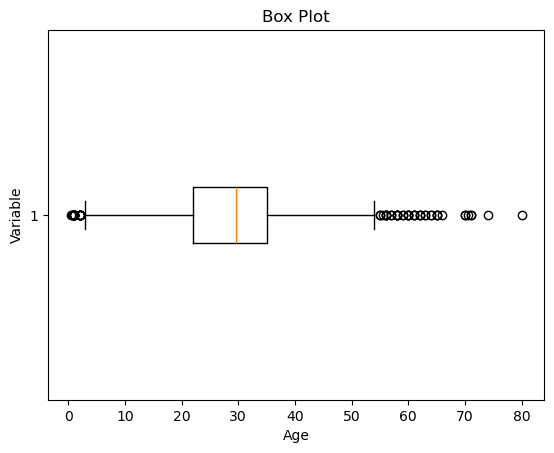

In [9]:
import matplotlib.pyplot as plt

plt.boxplot(df1['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

In [10]:
mean = df1['Age'].mean()
std = df1['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

df2 = df1[(df1['Age'] >= lower_bound) & (df1['Age'] <= upper_bound)]

In [11]:
df3 = df2.fillna(df2['Age'].mean())
df3.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [12]:
mean = df3['Age'].mean()
std = df3['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]

Lower Bound : 8.978989004171481
Upper Bound : 49.30395961288911


In [13]:
X = df3[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
Y = df3['Survived']

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

num_col_ = [col for col in X.columns if X[col].dtype != 'object']
x1 = X
x1[num_col_] = scaler.fit_transform(x1[num_col_])
x1.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_14160\1761829158.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x1[num_col_] = scaler.fit_transform(x1[num_col_])


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,male,0.349515,0.125,0.0,0.014151,S
1,0.0,female,0.660194,0.125,0.0,0.139136,C
2,1.0,female,0.427184,0.000,0.0,0.015469,S
3,0.0,female,0.601942,0.125,0.0,0.103644,S
4,1.0,male,0.601942,0.000,0.0,0.015713,S
